**Objectives:**

1. Implement conditional logic to route the flow of data to different nodes
2. Use START and END node to manage entry and exit points explicitly.
3. Design multiple nodes to perform different operations(addition, subtraction).
4. Create a router node to handle decision-making and control graph flow.

*Main Goal:* How to use *add_conditional_edges()*


In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [ ]:
#NOW OUR STATE SCHEMA
class AgentState(TypedDict):
    number1:int
    operation:str
    number2:int
    finalNumber:int

In [4]:
#create nodes
def adder(state: AgentState)-> AgentState:
    """This node adds two numbers"""

    state["finalNumber"]=state["number1"]+state["number2"]

    return state

def subtractor(state: AgentState)->AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"]=state["number1"]-state['number2']

    return state

#router
def decide_next_node(state:AgentState)->AgentState:
    """This node will select the next node of the graph"""
    if state['operation']=="+":
        return "addition_opeation"
    elif state['operation']=="-":
        return "subtraction_operation"


In [5]:
graph=StateGraph(AgentState)

#add the nodes
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)

#your input state will be the exact output state
graph.add_node("router", lambda state:state) #pass through function
graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "additional_operation":"add_node",
        "subtraction_operation":"subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

#compile the graph
app=graph.compile()


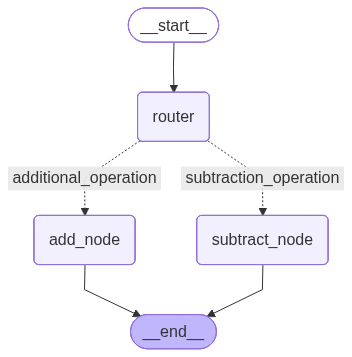

In [6]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
result=app.invoke({"number1":20, "number2":13, "operation":"-"})


In [8]:
result['finalNumber']

7